In [3]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np
#My scripts
import sys
sys.path.insert(1,'/data/rgallotti/libraries/PythonScripts/')
from rg_histograms import cumulative,histInt,histFloat,logHist
from rg_fits import power_fit

In [4]:
df_stop = pd.read_parquet('/data/shared/cuebiq/MOBS/export_boston_stops/part-00000-tid-8370822001034074384-743c94e0-1b4b-4ed5-bb82-36e53457948c-1927-1-c000.snappy.parquet')

In [5]:
df_stop.head()

,userId,clusterId,begin,end,geohash7
0,000df9bb1cea40da11b173894bb3af55b62e28d4d604a1...,116,2020-03-26 22:14:41,2020-03-26 22:39:42,drt2yzb
1,000df9bb1cea40da11b173894bb3af55b62e28d4d604a1...,116,2020-06-02 21:49:15,2020-06-02 22:04:21,drt2yzb
2,000df9bb1cea40da11b173894bb3af55b62e28d4d604a1...,116,2020-06-23 20:22:35,2020-06-23 20:32:34,drt2yzb
3,000df9bb1cea40da11b173894bb3af55b62e28d4d604a1...,116,2020-06-25 19:50:03,2020-06-25 20:24:20,drt2yzb
4,000df9bb1cea40da11b173894bb3af55b62e28d4d604a1...,116,2020-07-17 04:44:48,2020-07-17 05:12:08,drt2yzb


In [6]:
#mind there is already multiplicity of pois
df_poi = pd.read_parquet('/data/shared/cuebiq/MOBS/export_boston_pois/part-00000-tid-3649614229576010294-cf18ab81-29d7-4398-aa1b-f74093920e9b-2964-1-c000.snappy.parquet')
df_poi = df_poi[['userId','clusterId','name1_fs','name2_fs']].drop_duplicates()

In [7]:
df_poi

,userId,clusterId,name1_fs,name2_fs
0,0014eabc98e5b40df202a8b7294025f98dd6d8a04031af...,1,Food,Restaurant
47,00161d1b96595756cb8f2603d6bee9da4c6ba76a41361e...,83,Food,Food Court
48,0040018887bf3ce405c327f591602023f4a2841f46f945...,4,Professional & Other Places,Medical Center
50,00473db6df9c15fdd7848bebfdc4e0052ba9850deb70de...,4,Professional & Other Places,School
51,0055e6ca0662a2290b0f4923f2b67451e6854716594afe...,14,Shop & Service,IT Services
...,...,...,...,...
3104612,ffe4be4de761853892d089d90601c1a8dbd1300b8506a3...,76,Food,Fast Food Restaurant
3104613,ffeea7a71f47c284f82dd2c9234789928a5b1fd517c7d1...,47,Travel & Transport,Hotel
3104614,fff5116b31c94432f92eb04fad19230e50c7f99111386c...,53,Professional & Other Places,Medical Center
3104615,fff5116b31c94432f92eb04fad19230e50c7f99111386c...,105,Shop & Service,Pharmacy


In [4]:
#len(df_poi.drop_duplicates())

In [5]:
#df_stop['begin'] = pd.to_datetime(df_stop['begin'] )
df_stop['end'] = pd.to_datetime(df_stop['end'] )
df_stop['day'] = df_stop['end'].dt.date

In [6]:
dict_id = {r.userId:r.name for i,r in df_stop.userId.drop_duplicates().reset_index().iterrows()}

In [7]:
df_stop['userId'] = df_stop['userId'].map(dict_id)

In [8]:
df_poi['userId'] = df_poi['userId'].map(dict_id)

In [9]:
del dict_id

In [10]:
df_poi = pd.merge(df_stop,df_poi,on=['userId','clusterId'])

In [11]:
df = df_stop

In [12]:
len(df_stop)

8311442

number_days 213


<AxesSubplot:>

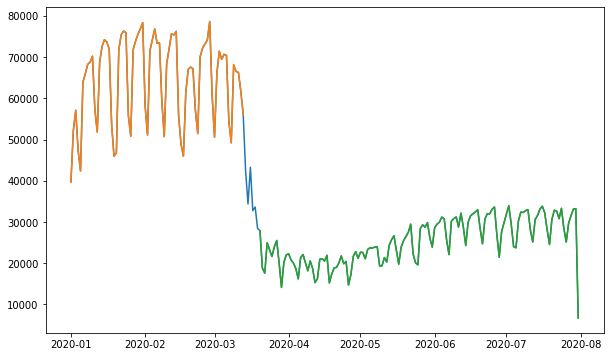

In [13]:
#Stops date aggr
num_stops = df.day.value_counts()
print('number_days',len(num_stops))


fig,ax = plt.subplots(figsize=(10,6))
num_stops.plot()

df[df.end < '2020-03-14'].day.value_counts().plot()
df[df.end >= '2020-03-20'].day.value_counts().plot()


number_users 179193


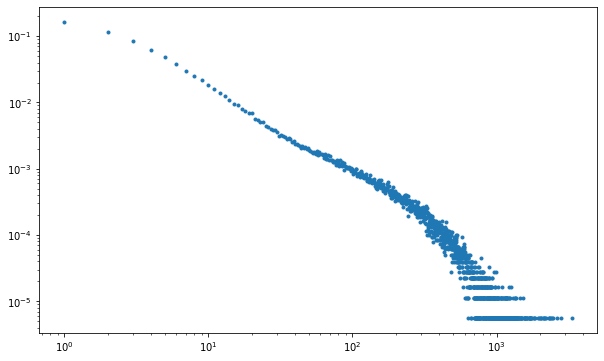

In [14]:
#Stops/User
num_stops = df.groupby('userId').userId.count()
print('number_users',len(num_stops))

w,q = histInt(num_stops)

fig,ax = plt.subplots(figsize=(10,6))
plt.loglog(q,w,'.')

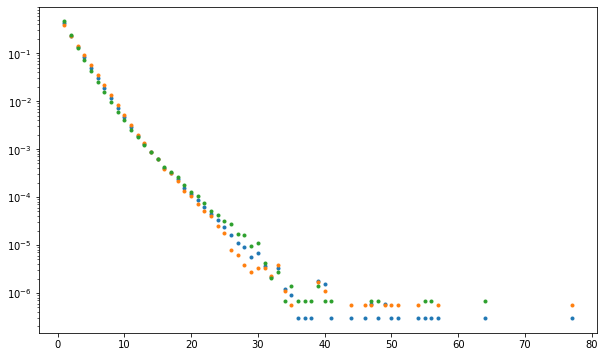

In [15]:
# Stops per day user
fig,ax = plt.subplots(figsize=(10,6))

num_stops = df.groupby(['userId','day']).geohash7.count()
w,q = histInt(num_stops)
plt.semilogy(q,w,'.')

num_stops_bf = df[df.end < '2020-03-14'].groupby(['userId','day']).geohash7.count()
w,q = histInt(num_stops_bf)
plt.semilogy(q,w,'.')

num_stops_af = df[df.end >= '2020-03-20'].groupby(['userId','day']).geohash7.count()
w,q = histInt(num_stops_af)
plt.semilogy(q,w,'.')

<AxesSubplot:xlabel='day'>

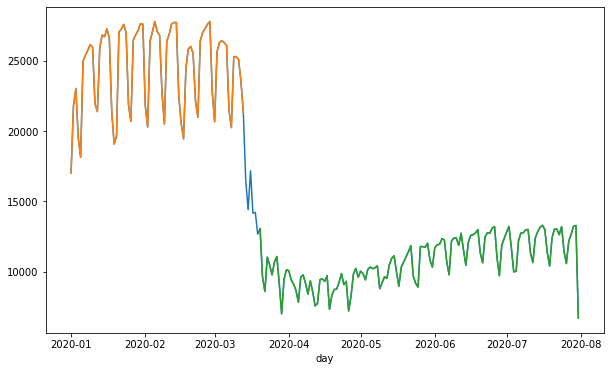

In [16]:
# User per day
num_stops = df.groupby('day').userId.nunique()

fig,ax = plt.subplots(figsize=(10,6))
df.groupby('day').userId.nunique().plot()

df[df.end < '2020-03-14'].groupby('day').userId.nunique().plot()
df[df.end >= '2020-03-20'].groupby('day').userId.nunique().plot()


In [17]:
print('Average users per day before:',df[df.end < '2020-03-14'].groupby('day').userId.nunique().mean(),'\n',
      
      'Average users per day after:',df[df.end >= '2020-03-20'].groupby('day').userId.nunique().mean())

Average users per day before: 24487.753424657534 
 Average users per day after: 10778.679104477613


# PoI diversity

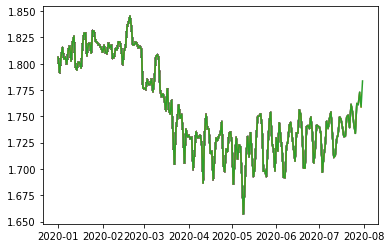

In [18]:
S = {}
for day, df_ in df_poi.groupby('day'):
    p = df_.name1_fs.value_counts().values
    p = p/sum(p)
    S[day] = np.sum(-p*np.log(p))
    pd.Series(S).plot()

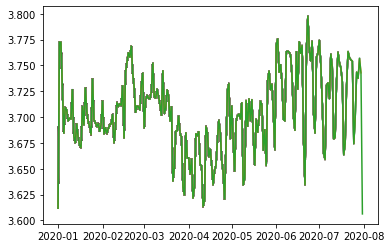

In [19]:
S = {}
for day, df_ in df_poi.groupby('day'):
    p = df_.name2_fs.value_counts().values
    p = p/sum(p)
    S[day] = np.sum(-p*np.log(p))
    pd.Series(S).plot()

# Stop Duration

In [128]:
def print_stop_dist(q,w):
    fig,ax = plt.subplots(figsize=(10,6))
    ax.lboglog(q,w)

    q1 = q[q<8*3600]
    w1 = w[q<8*3600]
    a1,b1,c1,d1 = power_fit(q1,w1)
    ax.loglog(q1,q1**a1*d1)


    q2 = q[q>24*3600]
    w2 = w[q>24*3600]
    a2,b2,c2,d2 = power_fit(q2,w2)

    ax.loglog(q2,q2**a2*d2)
    plt.title('%5.2f,%5.2f'%(a1,a2))

In [135]:
def print_residual(q,w):
    fig,ax = plt.subplots(figsize=(10,6))
    ax.loglog(q,w*q)



In [90]:
dt = (df_stop.end-df_stop.begin).dt.total_seconds()

w,q,dq = logHist(dt,100)


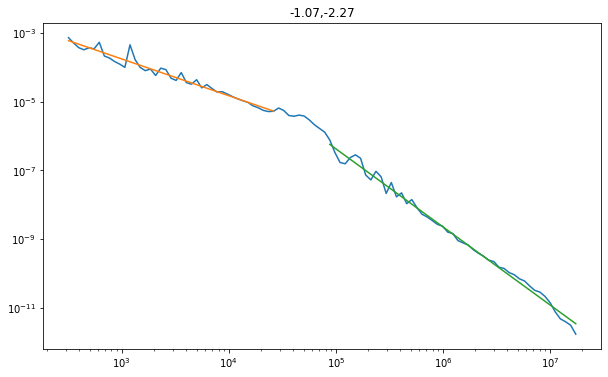

In [130]:
print_stop_dist(q,w)

In [132]:
df_before = df_stop[(df_stop.begin >= '2020-01-04') & (df_stop.end < '2020-03-14')]
df_after  = df_stop[(df_stop.begin >= '2020-03-21') & (df_stop.end < '2020-05-30')]

In [133]:
print(df_before.end.max() - df_before.begin.min())
print(df_after.end.max() - df_after.begin.min())

69 days 23:59:59
69 days 23:59:52


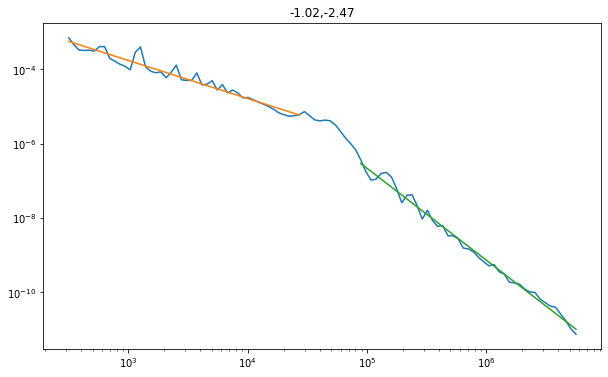

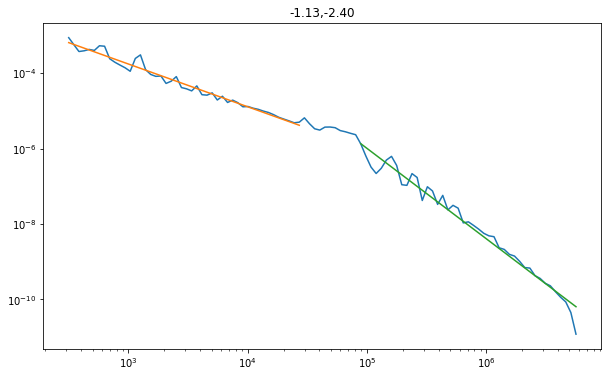

In [141]:
dtb = (df_before.end-df_before.begin).dt.total_seconds()

wb,qb,dqb = logHist(dtb,100)
print_stop_dist(qb,wb)

dta = (df_after.end-df_after.begin).dt.total_seconds()

wa,qa,dqa = logHist(dta,100)
print_stop_dist(qa,wa)

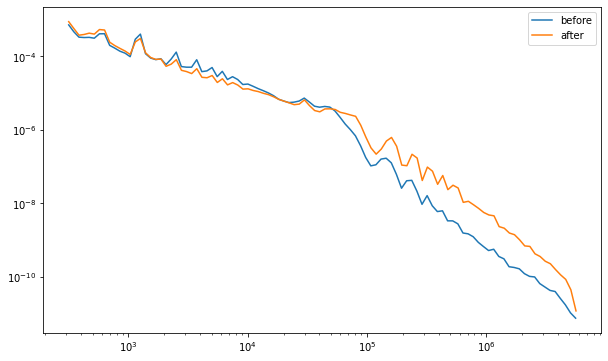

In [153]:
wb,qb,dqb = logHist(dtb,100)
wa,qa,dqa = logHist(dta,100)


fig,ax = plt.subplots(figsize=(10,6))
ax.loglog(qb,wb)
ax.loglog(qa,wa)
plt.legend(['before','after'])

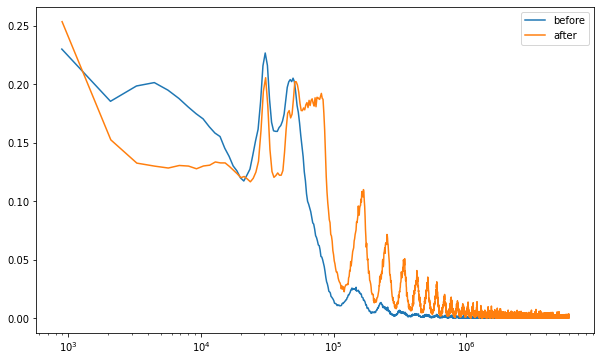

In [150]:
wb,qb = histFloat(dtb,5000)
wa,qa = histFloat(dta,5000)


fig,ax = plt.subplots(figsize=(10,6))
ax.semilogx(qb,wb*qb)
ax.semilogx(qa,wa*qa)
plt.legend(['before','after'])

# Good users: P(L), P(k), N(t), ...

In [38]:
user_counts = df.userId.value_counts()
user_counts_sel = user_counts[user_counts>df.day.nunique()]
len(user_counts_sel)/len(user_counts)

0.06237408827353747

In [43]:
df_ = df[df.userId == 1]
df_

,userId,clusterId,begin,end,geohash7,day
6,1,179,2020-02-06 17:04:32,2020-02-06 17:45:49,drt2wew,2020-02-06
7,1,583,2020-06-03 19:06:35,2020-06-03 19:17:37,drt2z7n,2020-06-03
78657,1,221,2020-02-19 16:24:16,2020-02-19 16:41:08,drt2ytt,2020-02-19
78658,1,221,2020-03-17 13:45:59,2020-03-17 13:52:05,drt2ytt,2020-03-17
78659,1,221,2020-03-17 14:07:49,2020-03-17 14:13:55,drt2ytt,2020-03-17
...,...,...,...,...,...,...
8184098,1,612,2020-06-08 12:17:32,2020-06-08 12:29:38,drt2yfb,2020-06-08
8184099,1,664,2020-06-16 13:04:19,2020-06-16 14:03:48,drt2yj1,2020-06-16
8224616,1,218,2020-02-18 18:05:48,2020-02-18 18:12:37,drt2zm2,2020-02-18
8224617,1,218,2020-03-10 14:19:54,2020-03-10 15:20:04,drt2zm2,2020-03-10


In [36]:
df_long = df[df.userId.isin(user_counts_sel.index)]

In [37]:
df_long[]

,userId,clusterId,begin,end,geohash7,day
6,1,179,2020-02-06 17:04:32,2020-02-06 17:45:49,drt2wew,2020-02-06
7,1,583,2020-06-03 19:06:35,2020-06-03 19:17:37,drt2z7n,2020-06-03
9,3,9,2020-01-11 17:55:02,2020-01-11 18:15:00,drt2zn8,2020-01-11
41,7,29,2020-02-17 18:19:43,2020-02-17 19:00:35,drt2zpk,2020-02-17
43,9,7,2020-03-09 15:36:58,2020-03-09 16:45:10,drt2x16,2020-03-09
...,...,...,...,...,...,...
8311435,7244,96,2020-02-07 15:15:01,2020-02-07 15:28:11,drt2zhm,2020-02-07
8311436,7244,96,2020-02-07 15:40:24,2020-02-07 15:59:24,drt2zhm,2020-02-07
8311437,7244,96,2020-03-07 16:09:29,2020-03-07 16:20:13,drt2zhm,2020-03-07
8311438,7244,96,2020-03-28 14:09:46,2020-03-28 14:17:21,drt2zhm,2020-03-28
